# Análisis Exploratorio de datos | Lending Club Data

## Introducción y contexto 
### Objetivo del analisis
#### Objetivo general 
- Construir y comparar modelos de clasificación supervisada con scikit-learn y Pyskpark para predecir el incumplimiento de pago (default) en préstamos de la plataforma Lending Club, evaluando el desempeño de este usando métricas estándar e interpretando las predicciones con LIME 

#### Objetivos especificos
- Explorar y comprender la estructura del dataset, identificando la distribución del target, valores faltantes y relaciones entre variables relevantes

- Preprocesar los datos en 2 entornos diferentes: scikit-learn y PySpark aplicando codificación de variables categóricas, escalado y división estratificada

- Entrenar un modelo ´RandomForestClassifier´ en ambos entornos, ajustando hiperparámetros usando métodos de búsqueda (e.g GridSearchCV en sklearn o manual en Pyspark)

- Evaluar y comparar el desempeño de ambos modelos con los 2 entornos diferentes usando métricas como Accuracy, Precision, Recall, F1-score y ROC AUC, también se incluye tiempos de cómputo

- Aplicar LIME sobre instancias mal clasificadas para interpretar las predicciones del modelo y entender que variables influyen en cada casa

### Contexto
El conjunto de datos que vamos a analizar fue publicado en la plataforma Kaggle y es de acceso libre. Corresponde a todos los préstamos emitidos por Lending Club entre los años 2007 y 2018. Es decir, cubre más de diez años de operaciones reales, lo cual nos da una perspectiva bastante amplia sobre cómo se comportan los préstamos a lo largo del tiempo. Lending Club es una empresa estadounidense de préstamos entre personas (lo que se conoce como peer-to-peer o P2P), con sede en San Francisco, California. Fue la primera empresa de este tipo en registrar sus operaciones como valores ante la Comisión de Bolsa y Valores de Estados Unidos, y en ofrecer negociación de préstamos en un mercado secundario. 

El conjunto de datos original es muy grande: incluye más de 2 millones de registros de préstamos, con 145 variables cada uno. En total, representa aproximadamente 34 mil millones de dólares en capital prestado, lo cual es una parte bastante significativa del total que la empresa dice haber intermediado.

## Dimensiones del conjunto de datos
Antes de comenzar con el análisis, es importante conocer las dimensiones exactas del dataset para tomar decisiones y como manejarlo.

In [7]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')



In [8]:
datos = pd.read_csv("/Users/pctm/Documents/archive/accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv")
pd.options.display.float_format = '{:,.2f}'.format
print(datos.info())



<class 'pandas.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Columns: 151 entries, id to settlement_term
dtypes: float64(113), object(1), str(37)
memory usage: 2.5+ GB
None


El dataset original cuenta con mas de 2.2 millones de registros y 151 columnas

### Creación de la variable objetivo
El dataset contiene prestamos en diferentes estados intermedios como "Current" o "Late. Para este proyecto solo interesan los prestamos con resultados fijos: pagados completamente o en default

In [9]:
df = datos[datos["loan_status"].isin(["Fully Paid", "Charged Off"])].copy()

df["default"] = df["loan_status"].apply(lambda x: 1 if x == "Charged Off" else 0)

df = df.drop(columns=["loan_status"])

print(f"Filas:    {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")

Filas:    1,345,310
Columnas: 151


Después de filtrarlo por prestamos con un resultado definitivo, nos quedaron 1.345.310 observaciones con 151 columnas . La columna `loan_status` fue reemplazada por `default`, donde 0 = Fully Paid y 1 = Charged Off

In [10]:
print(df.columns.tolist())

['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'acc_now_delinq', 'tot_coll_amt'

## Inspección general
Esta sección nos permite conocer las primeras filas del dataset, los tipos datos de cada column y un resumen estadístico básico. Esto con el fin de identificar rápidamente variables que podrían necesitar alguna transformación o limpieza

In [11]:
print(df.head())

         id  member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  \
0  68407277        NaN   3,600.00     3,600.00         3,600.00   36 months   
1  68355089        NaN  24,700.00    24,700.00        24,700.00   36 months   
2  68341763        NaN  20,000.00    20,000.00        20,000.00   60 months   
4  68476807        NaN  10,400.00    10,400.00        10,400.00   60 months   
5  68426831        NaN  11,950.00    11,950.00        11,950.00   36 months   

   int_rate  installment grade sub_grade  ... hardship_last_payment_amount  \
0     13.99       123.03     C        C4  ...                          NaN   
1     11.99       820.28     C        C1  ...                          NaN   
2     10.78       432.66     B        B4  ...                          NaN   
4     22.45       289.91     F        F1  ...                          NaN   
5     13.44       405.18     C        C3  ...                          NaN   

  disbursement_method debt_settlement_flag  debt_settlem

Se observan las primeras 5 filas del dataset con sus 151 columnas mencionadas anteriormente. También se identifican variables numéricas como `loan_amnt`, `int_rate`e `installment`, variables categóricas como `term`y `grade`y una cantidad relativamente notoria de valores faltantes especialmente en columnas relacionadas con liquidaciones (`settlement_amount`o `settlement_date`) y dificultades de pago (`hardship_last_payment_amount`) 

### Mutual Information
Esto nos va ayudar a medir que tanto nos ayuda cada variable a predecir si un préstamo va a resultar en default. Si una variable tiene un valor alto significa que tiene contiene información util para el modelo, si tiene un valor cercano a 0 significa que no aporta nada y puede eliminarse

In [12]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif

# Copia temporal para calcular MI sin modificar df original
df_temp = df.copy()

# Usamos label encoder para cambiar variables categóricas a numéricas en el df temporal q d
le = LabelEncoder()
categoricas = [col for col in df_temp.columns if df_temp[col].dtype == object or str(df_temp[col].dtype) == 'string' or df_temp[col].apply(type).eq(str).any()]


for col in categoricas:
    df_temp[col] = le.fit_transform(df_temp[col].astype(str))

# Mutual Information sobre todas las variables
X_temp = df_temp.drop(columns=["default"])
mi = mutual_info_classif(X_temp.fillna(0), df_temp["default"], random_state=42)
mi_series = pd.Series(mi, index=X_temp.columns).sort_values(ascending=False)

print(mi_series)

total_rec_prncp                      0.49
last_pymnt_amnt                      0.31
recoveries                           0.28
settlement_status                    0.27
last_fico_range_high                 0.27
                                     ... 
sec_app_collections_12_mths_ex_med   0.00
sec_app_chargeoff_within_12_mths     0.00
sec_app_num_rev_accts                0.00
sec_app_revol_util                   0.00
sec_app_inq_last_6mths               0.00
Length: 150, dtype: float64


In [30]:
mi_series.head(10)
cols_mi = mi_series.head(10).index.tolist()
print(cols_mi)

['total_rec_prncp', 'last_pymnt_amnt', 'recoveries', 'settlement_status', 'last_fico_range_high', 'last_fico_range_low', 'collection_recovery_fee', 'hardship_start_date', 'settlement_date', 'debt_settlement_flag_date']


Los resultados muestran que ⁠ policy_code`tiene el valor mas alto con 0.20 seguido de `initial_list_status`con 0.14 y `home_ownership ⁠ con 0.09. A continuación se eliminaran las variables con mutual information menor a 0.01

### Medidas básicas

Las medidas de tendencia central como la media, mediana, desviación estándar y la moda permiten entender el comportamiento típico de cada variable numérica del dataset

In [ ]:
print(df.describe().T)

                                    count      mean      std    min      25%  \
member_id                            0.00       NaN      NaN    NaN      NaN   
loan_amnt                    1,345,310.00 14,419.97 8,717.05 500.00 8,000.00   
funded_amnt                  1,345,310.00 14,411.56 8,713.12 500.00 8,000.00   
funded_amnt_inv              1,345,310.00 14,389.14 8,715.49   0.00 7,875.00   
int_rate                     1,345,310.00     13.24     4.77   5.31     9.75   
...                                   ...       ...      ...    ...      ...   
hardship_last_payment_amount     5,754.00    184.69   196.46   0.01    39.57   
settlement_amount               33,276.00  5,029.93 3,684.83  44.21 2,228.62   
settlement_percentage           33,276.00     47.69     7.31   0.20    45.00   
settlement_term                 33,276.00     13.16     8.24   0.00     6.00   
default                      1,345,310.00      0.20     0.40   0.00     0.00   

                                   50% 

El dataset cuenta con 114 variables numéricas. Variables importantes como `loan_amnt` tienen una media de 14.419 con valores que van desde 500 hasta 40.000, lo que indica una amplia variedad en los montos solicitados. La tasa de interés `int_rate`promedia es de 13.24% con un mínimo de 5.31% y un máximo de 30.99%. La variable `default` muestra una media de 0.20, lo cual significa que aproximadamente un 20% de los prestamos resultaron en default

### Metricas de dispersión
Las méricas de dispersión como el rango intercuartílico (IQR) permiten identificar que tan dispersos están los datos y detectar posibles valores atípicos

In [15]:
cols = df.select_dtypes(include=np.number).columns.tolist()

Q1 = df[cols].quantile(0.25)
Q3 = df[cols].quantile(0.75)
IQR = Q3 - Q1

print(Q1)
print(Q3)
print(IQR)

member_id                           NaN
loan_amnt                      8,000.00
funded_amnt                    8,000.00
funded_amnt_inv                7,875.00
int_rate                           9.75
                                 ...   
hardship_last_payment_amount      39.57
settlement_amount              2,228.62
settlement_percentage             45.00
settlement_term                    6.00
default                            0.00
Name: 0.25, Length: 114, dtype: float64
member_id                            NaN
loan_amnt                      20,000.00
funded_amnt                    20,000.00
funded_amnt_inv                20,000.00
int_rate                           15.99
                                  ...   
hardship_last_payment_amount      267.61
settlement_amount               6,884.24
settlement_percentage              50.00
settlement_term                    18.00
default                             0.00
Name: 0.75, Length: 114, dtype: float64
member_id                    

Se puede ver que `loan_amnt` tiene un IQR de 12.000 indicando que el 50% de los préstamos se encuentran entre 8.000 y 20.000.
La tasa de interés `int_rate` tiene un IQR del 6.24%, centrándose entre 9.75% y 15.99%.
Variables como `settlement_amount`y `hardship_last_payment_amount` muestran un IQR alto lo que nos indica alta variabilidad, aunque hay que tener en cuenta que estas columnas solo aplican para casos específicos como prestamos en dificultad o negociacion de deuda.

### Valores Faltantes
En esta sección verificaremos los valores faltantes

In [16]:
faltantes = df.isnull().sum().sort_values(ascending=False)
porcentaje = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(df["loan_amnt"].isnull().sum())
print(df["fico_range_high"].isnull().sum())
print(faltantes)
print(porcentaje)

0
0
next_pymnt_d                                  1345310
member_id                                     1345310
orig_projected_additional_accrued_interest    1341551
hardship_start_date                           1339556
hardship_status                               1339556
                                               ...   
out_prncp                                           0
initial_list_status                                 0
total_acc                                           0
revol_bal                                           0
default                                             0
Length: 151, dtype: int64
next_pymnt_d                                 100.00
member_id                                    100.00
orig_projected_additional_accrued_interest    99.72
hardship_start_date                           99.57
hardship_status                               99.57
                                              ...  
out_prncp                                      0.00
initial_list

Se encontraron varias variables con valores faltantes. Las mas notables siendo `next_pyment_d` y `member_id` con el 100% de sus datos faltantes. Otras variables como `hardship_start_date` y `hardship_status` tienen alrededor de 99.57% de datos faltantes, confirmando que estos solo se aplican para casos excepcionales. Variables importantes como `int_rate`, `default`, `loan_amnt` no tienen ningún valor faltante

### Distribución de la variable objetivo

A continuación, se mostrará la distribución de la variable objetivo

In [17]:
print(df["default"].value_counts())
print(df["default"].value_counts(normalize=True) * 100)

default
0    1076751
1     268559
Name: count, dtype: int64
default
0   80.04
1   19.96
Name: proportion, dtype: float64


Se puede ver en la distribución de la variable `default` que el 80.% de los prestamos fueron pagados completamente (0), mientras que el 19.96% de los prestamos resultaron en default, es decir, que la deuda se declaro incobrable (1). 

## Visualizaciones
Para las visualizaciones de esta sección, se usarán solo las 10 primeras variables del resultado de la ejecución del mutual information.

### Histogramas de variables numéricas
Acá se tomarán las variables numéricas total_rec_prncp,last_pymnt_amnt, recoveries, last_fico_range_high, last_fico_range_low, collection_recovery_fee.

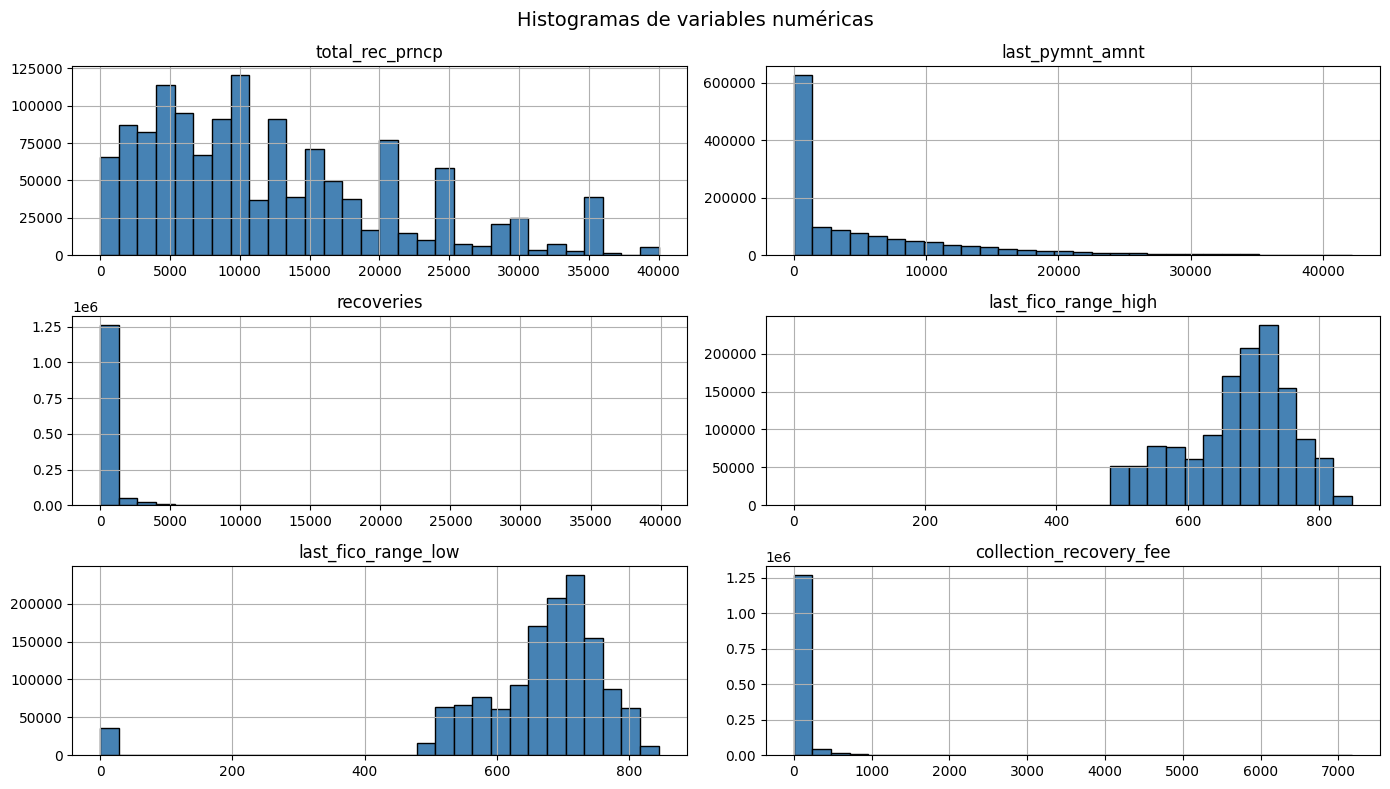

In [31]:
df[cols_mi].hist(bins=30, figsize=(14, 8), color="steelblue", edgecolor="black")
plt.suptitle("Histogramas de variables numéricas", fontsize=14)
plt.tight_layout()
plt.show()

Las variables total_rec_prncp y last_pymnt_amnt tienen sesgo a la derecha, la mayoría de préstamos tienen montos bajos, con pocos casos de valores muy altos. Por otro lado, recoveries y collection_recovery_fee tienen una distribución muy concentrada cerca de cero, lo que tiene sentido porque la mayoría de préstamos no llegan a recuperación/cobro. Los que sí llegan generan una cola larga son last_fico_range_high y last_fico_range_low que presentan una distribución más simétrica y centrada entre 600–800, que es el rango normal de puntajes FICO. Se ve una pequeña masa en cero que probablemente son registros sin dato.

### Boxplot por clase
En esta visualizacion se comparara la distribucion de cada variable entre prestamos pagados (0) y en default (1).

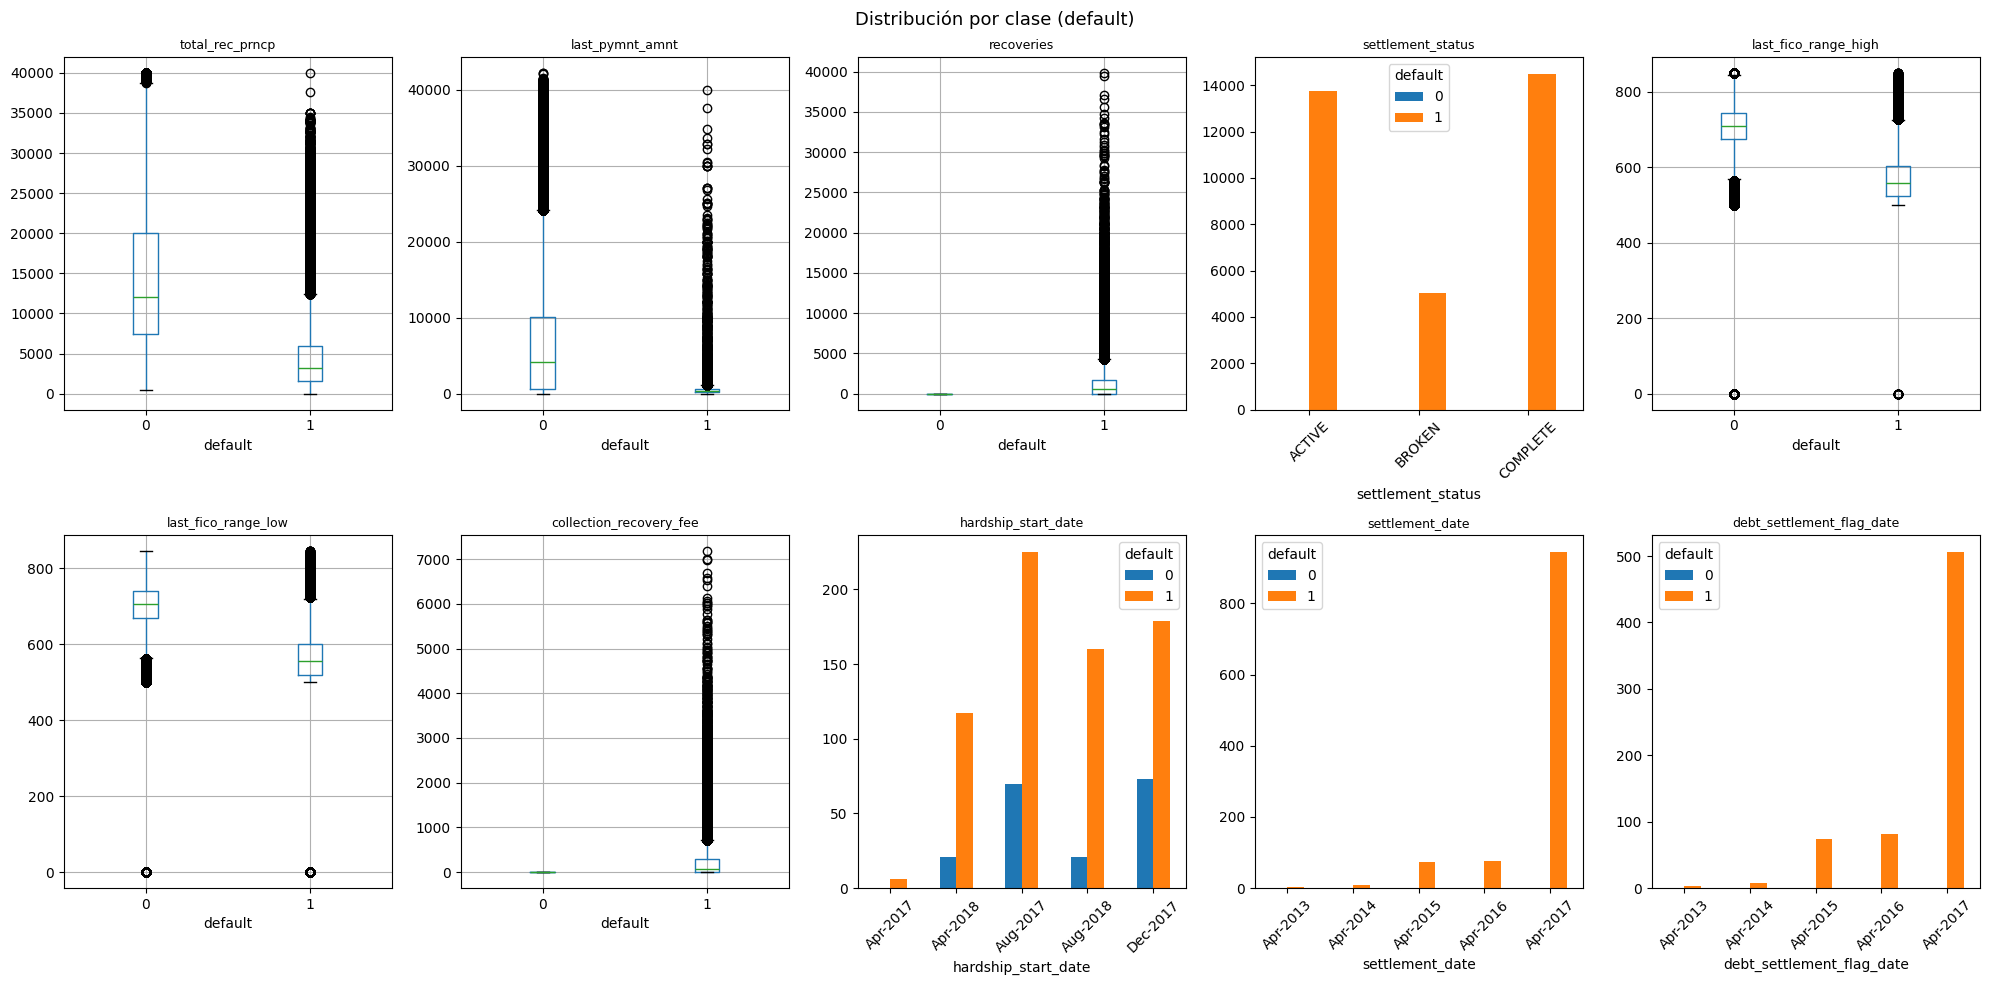

In [38]:
import math

cols_numericas = set(df[cols_mi].select_dtypes(include='number').columns)

n = len(cols_mi)
ncols = 5
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(cols_mi):
    if col in cols_numericas:
        df.boxplot(column=col, by="default", ax=axes[i])
        axes[i].set_title(col, fontsize=9)
    else:
        top5 = df.groupby("default")[col].value_counts().unstack(0).head(5)
        top5.plot(kind="bar", ax=axes[i], legend=True)
        axes[i].set_title(col, fontsize=9)
        axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribución por clase (default)", fontsize=13)
plt.tight_layout()
plt.show()

Para las variables numéricas, representadas por boxplots, los no-default tienen medianas más altas en total_rec_prncp y last_pymnt_amnt, lo que indica que quienes pagan bien amortizan más capital. En cambio, recoveries y collection_recovery_fee se concentran casi exclusivamente en default, ya que estos procesos solo se activan en impago. La separación más clara entre clases la dan last_fico_range_high y last_fico_range_low, pues los no-default tienen puntajes notablemente más altos, lo que las convierte en features muy útiles para un modelo predictivo. 

Por otro lado, las tres variables de fecha y settlement_status están casi completamente dominadas por la clase default (1), con mínima presencia de no-default. Esto sugiere que estas variables no aportan discriminación entre clases sino que simplemente describen consecuencias del impago, es decir, son variables que ocurren después del default, no antes, por lo que incluirlas en un modelo predictivo generaría data leakage y habría que descartarlas.

### Correlación
En esta visualización se podrá ver que variables numéricas están más relacionadas entre si y con la variable objetivo.

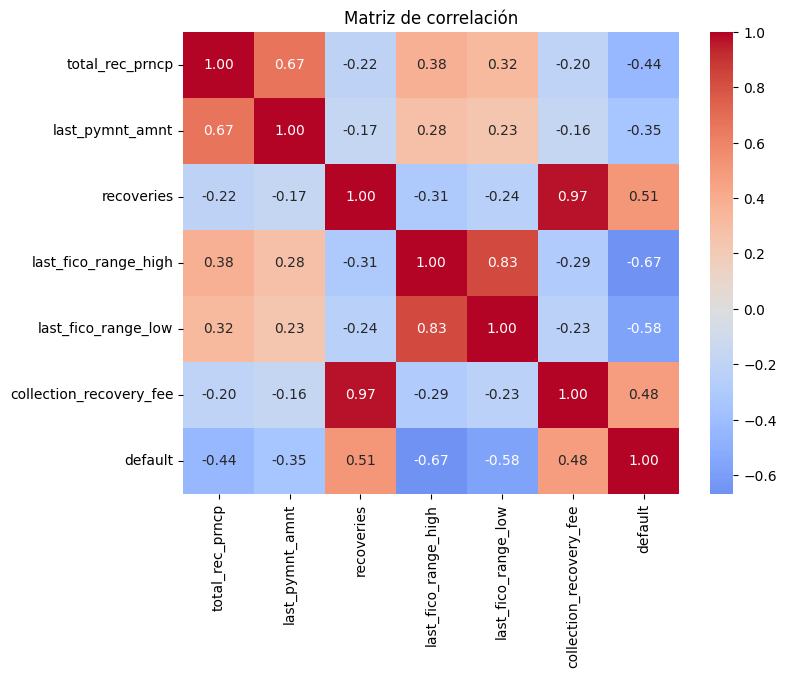

In [36]:
cols_numericas = df[cols].select_dtypes(include='number').columns.tolist()

corr = df[cols_numericas + ["default"]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación")
plt.show()

Las variables con mayor correlación con default son last_fico_range_high (-0.67) y last_fico_range_low (-0.58), confirmando que a mejor puntaje crediticio menor probabilidad de impago, mientras que recoveries (0.51) y collection_recovery_fee (0.48) correlacionan positivamente pero como ya vimos son consecuencias del default, no causas. Adicionalmente se observa multicolinealidad fuerte entre recoveries y collection_recovery_fee (0.97), y entre last_fico_range_high y last_fico_range_low (0.83).

### Distribucion de la variable objetivo 


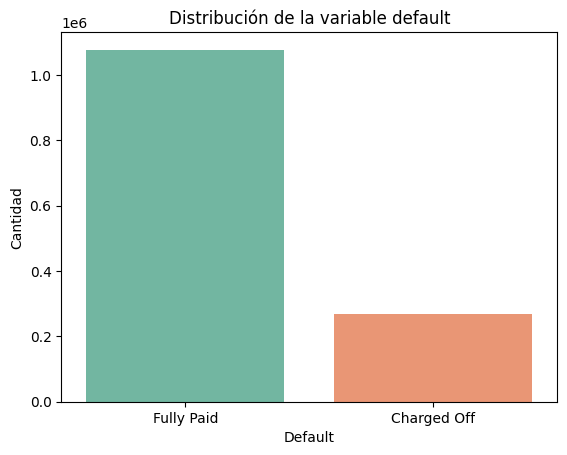

In [35]:
sns.countplot(x="default", data=df, palette="Set2")
plt.title("Distribución de la variable default")
plt.xlabel("Default")
plt.ylabel("Cantidad")
plt.xticks([0, 1], ["Fully Paid", "Charged Off"])
plt.show()

El gráfico muestra la clase 0 (Fully Paid) cuenta con aproximadamente 1.050.00 registros mientras que la clase 1(Charged Off) tiene aproximadamente 260.000 registros representando el 80% y 20% respectivamente